In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import gc

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from scipy.interpolate import griddata

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print(f"\n{'='*80}\n   1. ORAS5 CONFIGURATION\n{'='*80}")

DATA_DIR = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\BOXED")

REGION = {
    "lat_min": 25,
    "lat_max": 45,
    "lon_min": -50,
    "lon_max": -30,
}

FILE_RE = re.compile(r"ORAS5_(\d{4})_(\d{2})_(.+?)_boxed\.nc$")

MAX_MONTHS = 120
LOOKBACK = 12

DLAT = 0.5
DLON = 0.5

VAR_META = {
    "sst": {
        "token": "sst",
        "depth_mode": None,
    },

    "salinity": {
        "token": "so_salinity",
        "depth_mode": "0_100m",
    },
    "thetao": {
        "token": "thetao",
        "depth_mode": "0_100m",
    },
    "qnet": {
        "token": "heat",
        "depth_mode": None,
    },
    "u_current": {
        "token": "u_zonal",
        "depth_mode": "0_100m",
    },
    "v_current": {
        "token": "v_meridional",
        "depth_mode": "0_100m",
    },
}

print("ORAS5 directory:", DATA_DIR)
print("Region:", REGION)
print("Variables:", list(VAR_META.keys()))


   1. ORAS5 CONFIGURATION
ORAS5 directory: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\BOXED
Region: {'lat_min': 25, 'lat_max': 45, 'lon_min': -50, 'lon_max': -30}
Variables: ['sst', 'salinity', 'thetao', 'qnet', 'u_current', 'v_current']


In [2]:
print(f"\n{'='*80}\n   2. HELPER FUNCTIONS\n{'='*80}")

def open_nc(path):
    try:
        return xr.open_dataset(path, engine="h5netcdf")
    except Exception:
        return xr.open_dataset(path, engine="scipy")


def files_for_token(data_dir, token):
    all_nc = sorted(data_dir.rglob("*.nc"))
    out = [p for p in all_nc if FILE_RE.search(p.name) and token in p.name]
    return sorted(out)


def time_from_filename(path):
    m = FILE_RE.search(path.name)
    if m is None:
        raise ValueError(f"Filename does not match expected pattern: {path.name}")

    year = int(m.group(1))
    month = int(m.group(2))

    return pd.Timestamp(year=year, month=month, day=1)


def find_main_var(ds):
    ignore = {
        "time", "time_counter", "valid_time", "nav_time",
        "lat", "lon", "latitude", "longitude", "nav_lat", "nav_lon",
        "depth", "deptht", "depthu", "depthv", "nav_lev"
    }

    candidates = [k for k in ds.data_vars if k not in ignore]

    if len(candidates) == 0:
        raise ValueError(f"No usable variable found. Available data_vars={list(ds.data_vars)}")

    return candidates[0]


def find_coord_name(ds, options):
    for name in options:
        if name in ds.coords or name in ds.variables:
            return name

    return None


def normalise_longitude(lon):
    return xr.where(lon > 180, lon - 360, lon)


def subset_region(ds, region):
    lat_name = find_coord_name(ds, ["lat", "latitude", "nav_lat"])
    lon_name = find_coord_name(ds, ["lon", "longitude", "nav_lon"])

    if lat_name is None or lon_name is None:
        print("Warning: could not find lat/lon coords; skipping regional subset")
        return ds

    lat = ds[lat_name]
    lon = normalise_longitude(ds[lon_name])

    if lon_name in ds.coords:
        ds = ds.assign_coords({lon_name: lon})

    mask = (
        (lat >= region["lat_min"]) & (lat <= region["lat_max"]) &
        (lon >= region["lon_min"]) & (lon <= region["lon_max"])
    )

    return ds.where(mask, drop=True)


def depth_reduce_if_needed(da, ds, depth_mode):
    if depth_mode is None:
        return da

    for zname in ["depth", "deptht", "depthu", "depthv", "nav_lev"]:
        if zname in da.dims:
            if zname in da.coords:
                z = da[zname]
            elif zname in ds.coords:
                z = ds[zname]
            elif zname in ds.variables:
                z = ds[zname]
            else:
                z = xr.DataArray(np.arange(da.sizes[zname]), dims=[zname])

            if depth_mode == "0_100m":
                return da.where((z >= 0) & (z <= 100), drop=True).mean(dim=zname)

    return da


def clean_oras5_array(da):
    for tdim in ["time_counter", "valid_time", "nav_time", "time"]:
        if tdim in da.dims and da.sizes[tdim] == 1:
            da = da.isel({tdim: 0}, drop=True)

    for bdim in ["bnds", "bounds", "nbnds", "nv"]:
        if bdim in da.dims:
            da = da.isel({bdim: 0}, drop=True)

    da = da.squeeze(drop=True)

    if "y" in da.dims and "x" in da.dims:
        da = da.transpose("y", "x")

    return da.astype(np.float32)


def regrid_oras5_to_regular(da, region, dlat=0.5, dlon=0.5):
    nav_lat = da["nav_lat"].values
    nav_lon = da["nav_lon"].values
    nav_lon = np.where(nav_lon > 180, nav_lon - 360, nav_lon)

    values = da.values

    valid = (
        np.isfinite(nav_lat) &
        np.isfinite(nav_lon) &
        np.isfinite(values)
    )

    points = np.column_stack([
        nav_lon[valid],
        nav_lat[valid]
    ])

    target_lons = np.arange(region["lon_min"], region["lon_max"] + dlon, dlon)
    target_lats = np.arange(region["lat_min"], region["lat_max"] + dlat, dlat)

    lon2d, lat2d = np.meshgrid(target_lons, target_lats)

    linear = griddata(
        points,
        values[valid],
        (lon2d, lat2d),
        method="linear"
    )

    nearest = griddata(
        points,
        values[valid],
        (lon2d, lat2d),
        method="nearest"
    )

    regridded = np.where(np.isfinite(linear), linear, nearest)

    return xr.DataArray(
        regridded.astype(np.float32),
        dims=("lat", "lon"),
        coords={
            "lat": target_lats,
            "lon": target_lons,
        },
        name=da.name
    )


print("Helper functions ready.")


   2. HELPER FUNCTIONS
Helper functions ready.


In [3]:
print(f"\n{'='*80}\n   3. LOADING AND REGRIDDING MONTHLY ORAS5 VARIABLES\n{'='*80}")

file_dict = {}

for var_name, meta in VAR_META.items():
    paths = files_for_token(DATA_DIR, meta["token"])
    file_dict[var_name] = {time_from_filename(p): p for p in paths}
    print(f"{var_name:12s}: {len(paths)} files")

common_times = sorted(set.intersection(*[set(d.keys()) for d in file_dict.values()]))

if MAX_MONTHS is not None:
    common_times = common_times[:MAX_MONTHS]

print(f"\nCommon monthly timesteps: {len(common_times)}")
print(f"First: {common_times[0]}")
print(f"Last : {common_times[-1]}")

monthly_fields = []
used_times = []

for i, ts in enumerate(common_times, start=1):
    print(f"Loading {i}/{len(common_times)}: {ts.strftime('%Y-%m')}")

    var_arrays = []

    for var_name, meta in VAR_META.items():
        path = file_dict[var_name][ts]

        with open_nc(path) as ds:
            ds = subset_region(ds, REGION)
            vname = find_main_var(ds)

            da = ds[vname]
            da = depth_reduce_if_needed(da, ds, meta["depth_mode"])
            da = clean_oras5_array(da)

            da = regrid_oras5_to_regular(
                da,
                REGION,
                dlat=DLAT,
                dlon=DLON
            )

            var_arrays.append(da.load())

    stacked = xr.concat(var_arrays, dim="feature")
    stacked = stacked.assign_coords(feature=list(VAR_META.keys()))
    stacked = stacked.expand_dims(time=[np.datetime64(ts)])

    monthly_fields.append(stacked)
    used_times.append(ts)

oras5_monthly = xr.concat(
    monthly_fields,
    dim="time",
    coords="minimal",
    compat="override",
    join="override"
)

oras5_monthly.name = "oras5_regular_multivar"

print("\nFinal regridded ORAS5 monthly tensor:")
print(oras5_monthly)
print("Shape:", oras5_monthly.shape)


   3. LOADING AND REGRIDDING MONTHLY ORAS5 VARIABLES
sst         : 816 files
salinity    : 775 files
thetao      : 769 files
qnet        : 775 files
u_current   : 777 files
v_current   : 778 files

Common monthly timesteps: 120
First: 1958-01-01 00:00:00
Last : 1967-12-01 00:00:00
Loading 1/120: 1958-01
Loading 2/120: 1958-02
Loading 3/120: 1958-03
Loading 4/120: 1958-04
Loading 5/120: 1958-05
Loading 6/120: 1958-06
Loading 7/120: 1958-07
Loading 8/120: 1958-08
Loading 9/120: 1958-09
Loading 10/120: 1958-10
Loading 11/120: 1958-11
Loading 12/120: 1958-12
Loading 13/120: 1959-01
Loading 14/120: 1959-02
Loading 15/120: 1959-03
Loading 16/120: 1959-04
Loading 17/120: 1959-05
Loading 18/120: 1959-06
Loading 19/120: 1959-07
Loading 20/120: 1959-08
Loading 21/120: 1959-09
Loading 22/120: 1959-10
Loading 23/120: 1959-11
Loading 24/120: 1959-12
Loading 25/120: 1960-01
Loading 26/120: 1960-02
Loading 27/120: 1960-03
Loading 28/120: 1960-04
Loading 29/120: 1960-05
Loading 30/120: 1960-06
Loadin

In [4]:
print(f"\n{'='*80}\n   4. SCALING & SEQUENCE GENERATION\n{'='*80}")

# Shape before transpose:
# (time, feature, lat, lon)

# Shape after transpose:
# (time, lat, lon, feature)
data = oras5_monthly.transpose("time", "lat", "lon", "feature").values.astype(np.float32)

data[np.abs(data) > 1e10] = np.nan

print("Raw data shape:", data.shape)

# Standardise each feature separately
means = np.nanmean(data, axis=(0, 1, 2), keepdims=True)
stds = np.nanstd(data, axis=(0, 1, 2), keepdims=True)

data_scaled = (data - means) / (stds + 1e-8)

# Fill missing values with zero after standardisation
# Means missing values are replaced by the mean
data_scaled = np.nan_to_num(data_scaled, nan=0.0, posinf=0.0, neginf=0.0)

scaler = {
    "means": means,
    "stds": stds,
    "features": list(VAR_META.keys())
}

X, y = [], []

for i in range(data_scaled.shape[0] - LOOKBACK):
    X.append(data_scaled[i:i+LOOKBACK])
    y.append(data_scaled[i+LOOKBACK])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)

train_split = int(X.shape[0] * 0.70)
val_split = int(X.shape[0] * 0.85)

X_train, y_train = X[:train_split], y[:train_split]
X_val, y_val = X[train_split:val_split], y[train_split:val_split]
X_test, y_test = X[val_split:], y[val_split:]

target_times = pd.to_datetime(oras5_monthly.time.values)[LOOKBACK:]

train_times = target_times[:train_split]
val_times = target_times[train_split:val_split]
test_times = target_times[val_split:]

print(f"TRAIN: {train_times[0]} to {train_times[-1]}")
print(f"VAL  : {val_times[0]} to {val_times[-1]}")
print(f"TEST : {test_times[0]} to {test_times[-1]}")

gc.collect()


   4. SCALING & SEQUENCE GENERATION
Raw data shape: (120, 41, 41, 6)
X shape: (108, 12, 41, 41, 6)
y shape: (108, 41, 41, 6)
TRAIN: 1959-01-01 00:00:00 to 1965-03-01 00:00:00
VAL  : 1965-04-01 00:00:00 to 1966-07-01 00:00:00
TEST : 1966-08-01 00:00:00 to 1967-12-01 00:00:00


20

In [5]:
print(f"\n{'='*80}\n   5. TRAINING ORAS5 CONVLSTM\n{'='*80}")

_, time_steps, n_lat, n_lon, n_features = X_train.shape

model = Sequential([
    ConvLSTM2D(
        16,
        (3, 3),
        padding="same",
        return_sequences=True,
        input_shape=(time_steps, n_lat, n_lon, n_features)
    ),
    BatchNormalization(),

    ConvLSTM2D(
        16,
        (3, 3),
        padding="same",
        return_sequences=False
    ),
    BatchNormalization(),

    Conv2D(
        n_features,
        (3, 3),
        activation="linear",
        padding="same"
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model.summary()

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        "best_oras5_regular_convlstm.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=4,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete.")


   5. TRAINING ORAS5 CONVLSTM


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)             │ (None, 12, 41, 41, 16)      │          12,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 12, 41, 41, 16)      │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)           │ (None, 41, 41, 16)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 41, 41, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 41, 41, 6)           │             870 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,230 (125.90 KB)

 Trainable params: 32,166 (125.65 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 230ms/step - loss: 0.9753 - mae: 0.6661 - val_loss: 0.7883 - val_mae: 0.6000 - learning_rate: 0.0010
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - loss: 0.5685 - mae: 0.4762 - val_loss: 0.7061 - val_mae: 0.5651 - learning_rate: 0.0010
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 181ms/step - loss: 0.4341 - mae: 0.4088 - val_loss: 0.6660 - val_mae: 0.5506 - learning_rate: 0.0010
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 187ms/step - loss: 0.3820 - mae: 0.3864 - val_loss: 0.6487 - val_mae: 0.5457 - learning_rate: 0.0010
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - loss: 0.3589 - mae: 0.3784 - val_loss: 0.6169 - val_mae: 0.5254 - learning_rate: 0.0010
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - loss: 0.3388 - mae: 0.3674 - val_loss: 0.5941 - val_mae: 0.5136 - learning_rate: 0.0010
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - loss: 0.3045 - mae: 0.3387 - val_loss: 0.5728 - val_mae: 0.5054 - learning_rate: 0.0010
Epoch

In [6]:
print(f"\n{'='*80}\n   6. TEST PREDICTIONS\n{'='*80}")

from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = load_model("best_oras5_regular_convlstm.keras")

y_pred = model.predict(X_test)

y_pred_unscaled = (y_pred * scaler["stds"]) + scaler["means"]
y_test_unscaled = (y_test * scaler["stds"]) + scaler["means"]

for i, feature in enumerate(scaler["features"]):
    truth = y_test_unscaled[..., i].flatten()
    pred = y_pred_unscaled[..., i].flatten()

    mask = np.isfinite(truth) & np.isfinite(pred)

    mae = mean_absolute_error(truth[mask], pred[mask])
    rmse = np.sqrt(mean_squared_error(truth[mask], pred[mask]))
    r2 = r2_score(truth[mask], pred[mask])

    print(f"{feature:12s} | MAE = {mae:.4f} | RMSE = {rmse:.4f} | R² = {r2:.4f}")


   6. TEST PREDICTIONS
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
sst          | MAE = 1.0508 | RMSE = 1.3468 | R² = 0.8735
salinity     | MAE = 0.1400 | RMSE = 0.2123 | R² = 0.9124
thetao       | MAE = 0.6810 | RMSE = 0.9358 | R² = 0.9253
qnet         | MAE = 69.4815 | RMSE = 94.0690 | R² = 0.6817
u_current    | MAE = 0.0346 | RMSE = 0.0590 | R² = 0.4557
v_current    | MAE = 0.0315 | RMSE = 0.0583 | R² = 0.4686


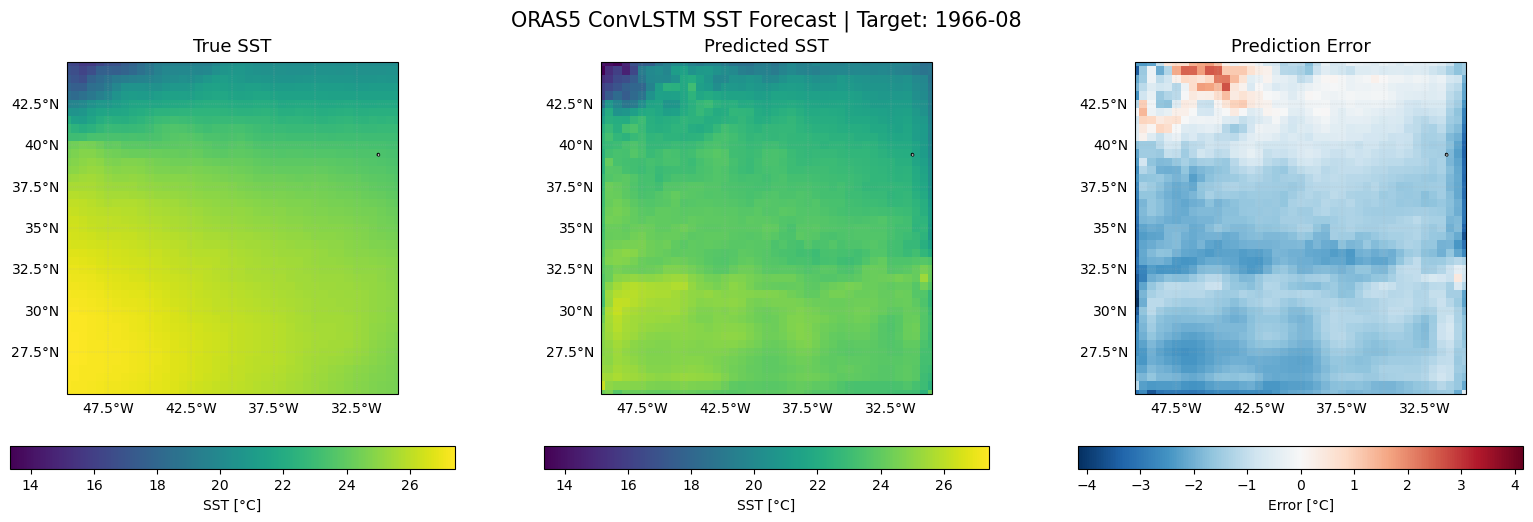

In [7]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np

sample_idx = 0
feature_name = "sst"
feature_idx = scaler["features"].index(feature_name)

truth = y_test_unscaled[sample_idx, :, :, feature_idx]
pred = y_pred_unscaled[sample_idx, :, :, feature_idx]
error = pred - truth

lats = oras5_monthly["lat"].values
lons = oras5_monthly["lon"].values
lon2d, lat2d = np.meshgrid(lons, lats)

proj = ccrs.PlateCarree()

# Shared scale for true and predicted SST
sst_vmin = np.nanmin([truth, pred])
sst_vmax = np.nanmax([truth, pred])

# Symmetric scale for error
err_abs = np.nanmax(np.abs(error))

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 4.8),
    subplot_kw={"projection": proj},
    constrained_layout=True
)

plot_data = [
    (truth, "True SST", "SST [°C]", sst_vmin, sst_vmax, "viridis"),
    (pred, "Predicted SST", "SST [°C]", sst_vmin, sst_vmax, "viridis"),
    (error, "Prediction Error", "Error [°C]", -err_abs, err_abs, "RdBu_r"),
]

for ax, (field, title, cbar_label, vmin, vmax, cmap) in zip(axes, plot_data):

    mesh = ax.pcolormesh(
        lon2d,
        lat2d,
        field,
        transform=proj,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_extent(
        [
            REGION["lon_min"],
            REGION["lon_max"],
            REGION["lat_min"],
            REGION["lat_max"]
        ],
        crs=proj
    )

    ax.add_feature(cfeature.LAND, facecolor="lightgrey", edgecolor="black", linewidth=0.5, zorder=3)
    ax.coastlines(resolution="50m", linewidth=0.6)

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.3,
        alpha=0.5,
        linestyle="--"
    )

    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(title, fontsize=13, pad=8)

    cbar = fig.colorbar(
        mesh,
        ax=ax,
        orientation="horizontal",
        pad=0.08,
        shrink=0.85
    )

    cbar.set_label(cbar_label)

fig.suptitle(
    f"ORAS5 ConvLSTM SST Forecast | Target: {test_times[sample_idx].strftime('%Y-%m')}",
    fontsize=15,
    y=1.05
)

plt.show()